In [64]:
# Section 1 — Imports, Seed, Constants
import os, json, math, re, random, datetime as _dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
import json
import yfinance as yf
import mplfinance as mpf
import tensorflow as tf
from typing import Optional, Dict

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, precision_recall_fscore_support, confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Dense, Dropout
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score

import time
from typing import Optional, Dict
from sklearn.preprocessing import MinMaxScaler
from joblib import dump

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import os, re

# Reproducibility
def set_global_seed(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
set_global_seed(42)


In [65]:
# Project constants 
COMPANY   = "CBA.AX"
START     = "2020-01-01"
END       = "2023-08-01"

DATE_COL  = "Date"
CLOSE_COL = "Close"

TEST_SIZE    = 0.20
TIME_STEP    = 60
FUTURE_DAYS  = 10
RANDOM_STATE = 42

# output dirs
RESULTS_DIR = "./results"
for sub in ["c3","c4","c5","c6","c7"]:
    os.makedirs(os.path.join(RESULTS_DIR, sub), exist_ok=True)
os.makedirs("./models_c6", exist_ok=True)
os.makedirs("./models_c7", exist_ok=True)

# Matplotlib defaults
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [ ]:
# Section 2 — Load & Clean Data (final)

DATE_COL = "Date"   

def fetch_prices(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=False)
    if df.empty:
        raise ValueError(f"No data returned for {ticker}.")

    # Flatten MultiIndex if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Standardise column names
    cols = {c: c.strip() for c in df.columns}
    df = df.rename(columns=cols)

    # Keep BOTH Close and Adj Close 
    if "Adj Close" in df.columns:
        df = df.rename(columns={"Adj Close": "AdjClose"})
    # If AdjClose is missing, clone from Close so feature_cols won't break
    if "AdjClose" not in df.columns and "Close" in df.columns:
        df["AdjClose"] = df["Close"]

    # Reset and rename date column, then set a proper DateTimeIndex
    df = df.reset_index().rename(columns={"Date": DATE_COL})
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce").dt.tz_localize(None)
    df = df.sort_values(DATE_COL).set_index(DATE_COL)

    # Basic cleanup
    df = df.ffill().bfill()

    # Final column order if available
    ordered = [c for c in ["Open","High","Low","Close","AdjClose","Volume"] if c in df.columns]
    df = df[ordered + [c for c in df.columns if c not in ordered]]

    return df


In [ ]:
# Section 2B — Cached Loader 

def _is_cache_fresh(path: str, max_age_days: int) -> bool:
    if not os.path.exists(path): 
        return False
    age_days = (time.time() - os.path.getmtime(path)) / 86400.0
    return age_days <= max_age_days

def _cache_write(df: pd.DataFrame, path: Optional[str]):
    if not path: 
        return
    os.makedirs(os.path.dirname(path), exist_ok=True)
    ext = os.path.splitext(path)[1].lower()
    if ext in (".parquet", ".pq"):
        try:
            df.to_parquet(path)  # requires pyarrow/fastparquet
            return
        except Exception:
            path = os.path.splitext(path)[0] + ".csv"
    df.to_csv(path, index=True)

def _cache_read(path: Optional[str]) -> Optional[pd.DataFrame]:
    if not path or not os.path.exists(path):
        return None
    ext = os.path.splitext(path)[1].lower()
    try:
        if ext in (".parquet", ".pq"):
            try:
                return pd.read_parquet(path)
            except Exception:
                alt = os.path.splitext(path)[0] + ".csv"
                if os.path.exists(alt):
                    return pd.read_csv(alt, index_col=0, parse_dates=True)
                return None
        elif ext == ".csv":
            return pd.read_csv(path, index_col=0, parse_dates=True)
        else:
            return pd.read_csv(path, index_col=0, parse_dates=True)
    except Exception:
        return None

def load_process_data(
    ticker: str,
    start: str,
    end: str,
    split_mode: str = "date",          # "date" | "ratio" | "random"
    split_arg: Optional[str] = None,   # e.g. "2024-01-01" when split_mode="date"
    split_ratio: float = 0.8,
    shuffle_random: bool = False,
    scale: bool = True,
    cache_path: Optional[str] = None,  # e.g. "cache/AAPL.csv"
    scaler_path: Optional[str] = None, # optional joblib path
    cache_max_age_days: int = 7,
    nan_strategy: str = "ffill_then_drop"
) -> Dict[str, object]:
    
    # Load (with cache)
    df = None
    if cache_path and _is_cache_fresh(cache_path, cache_max_age_days):
        df = _cache_read(cache_path)
    if df is None:
        df = fetch_prices(ticker, start, end)
        # NaNs
        if nan_strategy == "ffill_then_drop":
            df = df.ffill().dropna()
        elif nan_strategy == "drop":
            df = df.dropna()
        elif nan_strategy == "interpolate":
            df = df.interpolate().dropna()
        else:
            raise ValueError("Unknown nan_strategy")
        _cache_write(df, cache_path)

    # Ensure we have a DateTimeIndex (some CSV loads may come back with index as str)
    if not isinstance(df.index, pd.DatetimeIndex):
        if "Date" in df.columns:
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            df = df.set_index("Date")
        else:
            df.index = pd.to_datetime(df.index, errors="coerce")

    # Dynamic feature cols (use what's available)
    base_cols = ["Open","High","Low","Close","AdjClose","Volume"]
    feature_cols = [c for c in base_cols if c in df.columns]

    # Split
    if split_mode == "date":
        assert split_arg is not None, "Provide split_arg='YYYY-MM-DD' for split_mode='date'"
        cut = pd.to_datetime(split_arg)
        df_train = df[df.index < cut].copy()
        df_test  = df[df.index >= cut].copy()
    elif split_mode == "ratio":
        cut = int(len(df) * split_ratio)
        df_train = df.iloc[:cut].copy()
        df_test  = df.iloc[cut:].copy()
    elif split_mode == "random":
        idx = np.arange(len(df))
        tr, te = train_test_split(idx, train_size=split_ratio, shuffle=shuffle_random, random_state=42)
        df_train = df.iloc[np.sort(tr)].copy()
        df_test  = df.iloc[np.sort(te)].copy()
    else:
        raise ValueError("split_mode must be 'date'|'ratio'|'random'")

    scaler = None
    if scale and feature_cols:
        scaler = MinMaxScaler()
        scaler.fit(df_train[feature_cols])
        df_train[feature_cols] = scaler.transform(df_train[feature_cols])
        df_test[feature_cols]  = scaler.transform(df_test[feature_cols])
        if scaler_path:
            try:
                from joblib import dump
                os.makedirs(os.path.dirname(scaler_path), exist_ok=True)
                dump(scaler, scaler_path)
            except Exception:
                pass

    return {
        "df": df,
        "df_train": df_train,
        "df_test": df_test,
        "feature_cols": feature_cols,
        "scaler": scaler,
    }


In [ ]:
# Section 3 — Scale Features & Sequences 

def scale_features(df, scaler_type="minmax"):
    feature_candidates = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    feature_cols = [c for c in feature_candidates if c in df.columns]

    X = df[feature_cols].values
    y = df["Close"].values

    if scaler_type == "minmax":
        scaler = MinMaxScaler()
    else:
        scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)
    return X_scaled, y, scaler, feature_cols

def make_sequences(data, time_step=60):
    X, y = [], []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, 0]) 
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_scaled, y_all, feature_scaler, feature_cols = scale_features(df, scaler_type="minmax")
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)


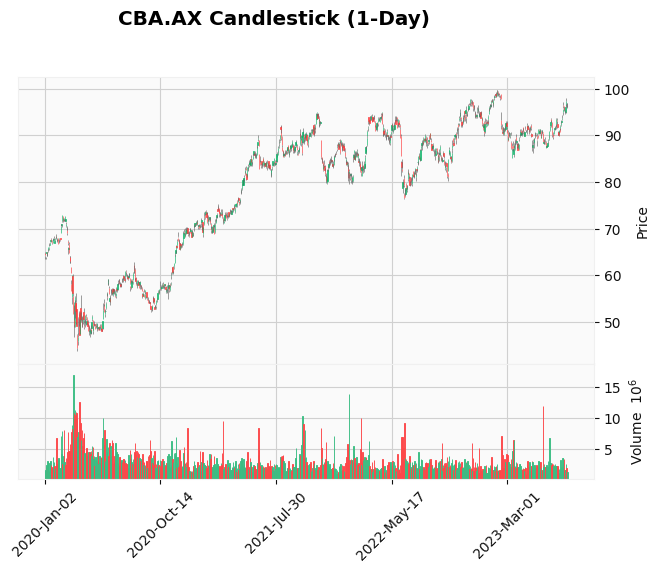

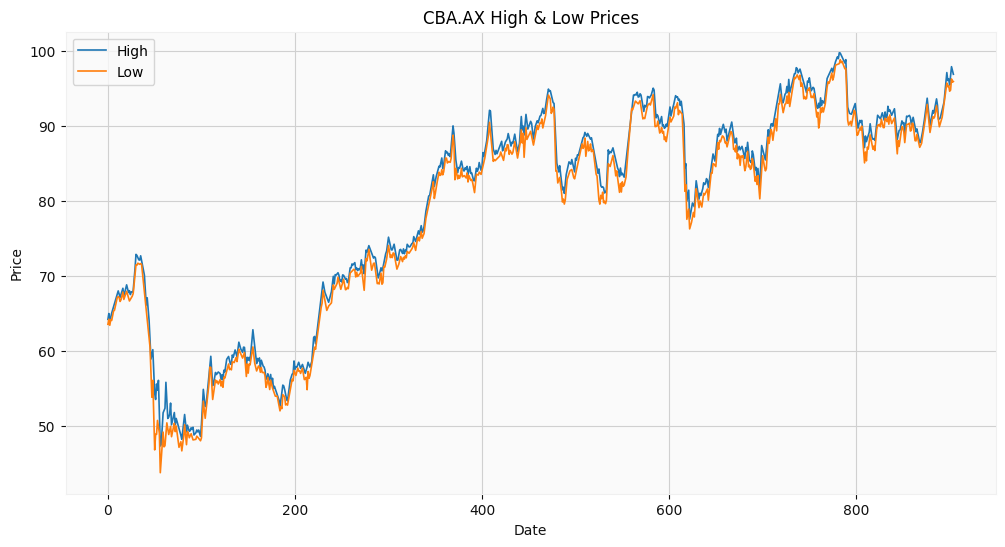

In [69]:
# Section 4 — Visualisations
def plot_candlestick(df, ticker, n=1):
    tmp = df.copy()
    if n > 1:
        tmp = tmp.resample(f'{n}D', on=DATE_COL).agg({
            'Open': 'first',
            'High': 'max',
            'Low': 'min',
            'Close': 'last',
            'Volume': 'sum'
        }).dropna().reset_index()
    mpf.plot(tmp.set_index(DATE_COL), type="candle", volume=True, style="yahoo",
             title=f"{ticker} Candlestick ({n}-Day)")

def plot_boxplot(data, n=5):
    closes = np.asarray(data['Close'], dtype=float)
    if len(closes) < n: 
        return
    windows = [closes[i:i+n] for i in range(len(closes)-n+1)]
    plt.figure(figsize=(10,6))
    plt.boxplot(windows, positions=range(len(windows)))
    plt.title(f"Boxplot of {n}-day windows of Closing Prices")
    plt.xlabel("Window index"); plt.ylabel("Closing Price"); plt.show()

def plot_high_low(df, ticker):
    plt.figure(figsize=(12,6))
    plt.plot(df["High"], label="High", linewidth=1.2)
    plt.plot(df["Low"], label="Low", linewidth=1.2)
    plt.title(f"{ticker} High & Low Prices"); plt.xlabel("Date"); plt.ylabel("Price")
    plt.legend(); plt.show()

def plot_true_vs_pred(ticker, true_prices, pred_prices, title_extra=""):
    plt.figure(figsize=(12,6))
    plt.plot(true_prices, label=f"Actual {ticker} Price", linewidth=1.2)
    plt.plot(pred_prices, label=f"Predicted {ticker} Price", linewidth=1.2)
    plt.title(f"{ticker} True vs Predicted Prices {title_extra}")
    plt.xlabel("Time"); plt.ylabel("Price"); plt.legend(); plt.show()

# quick EDA 
plot_candlestick(df, COMPANY)
plot_high_low(df, COMPANY)
# plot_boxplot(df, n=10)


In [ ]:
# Section 5 — Dataset Builders
def make_windows_multistep(
    df: pd.DataFrame,
    feature_cols,
    target_col: str = "Close",
    lookback: int = 60,
    horizon: int = 5
):
    
    values = df[feature_cols].values
    target = df[target_col].values
    X, y = [], []
    for i in range(lookback, len(df) - horizon + 1):
        X.append(values[i - lookback: i, :])
        y.append(target[i: i + horizon])
    return np.array(X), np.array(y)

def make_multivariate_data(df, features, target_col="Close", time_step=60):
    X, y = [], []
    data = df[features].values
    target = df[target_col].values
    for i in range(len(df) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(target[i + time_step])
    return np.array(X), np.array(y)

def make_multivariate_multistep_data(df, features, target_col="Close", time_step=60, future_days=5):
    X, y = [], []
    data = df[features].values
    target = df[target_col].values
    for i in range(len(df) - time_step - future_days + 1):
        X.append(data[i:(i + time_step)])
        y.append(target[(i + time_step):(i + time_step + future_days)])
    return np.array(X), np.array(y)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
CBA.AX RMSE: 4.0945 | MAE: 3.4362


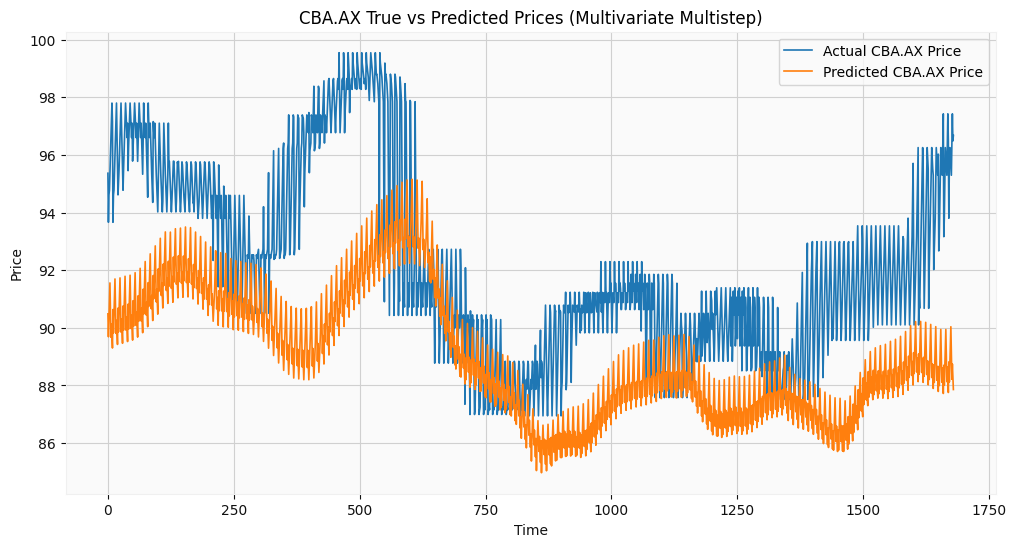

In [71]:
# Section 6 — DL Model Factory + Train
def build_dl_model(layer_type="LSTM", layer_sizes=[50], input_shape=(60, 1), dropout=0.2, 
                   output_units=1, optimizer="adam", loss="mse", metrics=["mae"]):
    model = Sequential()
    RNNLayer = {"LSTM": LSTM, "GRU": GRU, "RNN": SimpleRNN}[layer_type]
    for i, units in enumerate(layer_sizes):
        return_sequences = (i < len(layer_sizes) - 1)
        if i == 0:
            model.add(RNNLayer(units, return_sequences=return_sequences, input_shape=input_shape))
        else:
            model.add(RNNLayer(units, return_sequences=return_sequences))
        if dropout > 0:
            model.add(Dropout(dropout))
    model.add(Dense(output_units))
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

# Build multivariate-multistep dataset from scaled_df 
X, y = make_multivariate_multistep_data(
    scaled_df, feature_cols, target_col="Close", time_step=TIME_STEP, future_days=FUTURE_DAYS
)
cut = int(len(X) * (1 - TEST_SIZE))
X_train, X_test = X[:cut], X[cut:]
y_train, y_test = y[:cut], y[cut:]

# Train 
model = build_dl_model(
    layer_type="LSTM",
    layer_sizes=[50, 50],
    input_shape=(TIME_STEP, X_train.shape[2]),
    dropout=0.2,
    output_units=FUTURE_DAYS,
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
history = model.fit(X_train, y_train, epochs=24, batch_size=32, verbose=0)

# Predict (scaled space)
pred_scaled = model.predict(X_test)

# Inverse-transform predictions & truth to REAL prices 
close_idx = feature_cols.index("Close")
dummy_pred = np.zeros((pred_scaled.shape[0] * pred_scaled.shape[1], len(feature_cols)))
dummy_true = np.zeros((y_test.shape[0] * y_test.shape[1], len(feature_cols)))
dummy_pred[:, close_idx] = pred_scaled.reshape(-1)
dummy_true[:, close_idx] = y_test.reshape(-1)

pred_real_flat = feature_scaler.inverse_transform(dummy_pred)[:, close_idx]
true_real_flat = feature_scaler.inverse_transform(dummy_true)[:, close_idx]

rmse = math.sqrt(mean_squared_error(true_real_flat, pred_real_flat))
mae  = mean_absolute_error(true_real_flat, pred_real_flat)
print(f"{COMPANY} RMSE: {rmse:.4f} | MAE: {mae:.4f}")

plot_true_vs_pred(COMPANY, true_real_flat, pred_real_flat, title_extra="(Multivariate Multistep)")
# keep for ARIMA/ensemble alignment
y_pred_mvms_real_test = pred_real_flat.copy()


X_train_seq: (664, 60, 1) | X_test_seq: (121, 60, 1)

------------------------------------------------------------------
Total experiments to run: 3
[1/3] Baseline_LSTM_Single — LSTM [50], epochs=15, batch=32, dropout=0.2
[2/3] Baseline_GRU_Single — GRU [50], epochs=15, batch=32, dropout=0.2
[3/3] Baseline_RNN_Single — RNN [50], epochs=15, batch=32, dropout=0.2
All experiments completed.

Top 5 models by RMSE (real scale):
     experiment_name model_type layer_architecture  rmse_real  mae_real
 Baseline_RNN_Single        RNN               [50]   1.379340  1.108084
 Baseline_GRU_Single        GRU               [50]   1.476991  1.127087
Baseline_LSTM_Single       LSTM               [50]   2.448272  1.812951


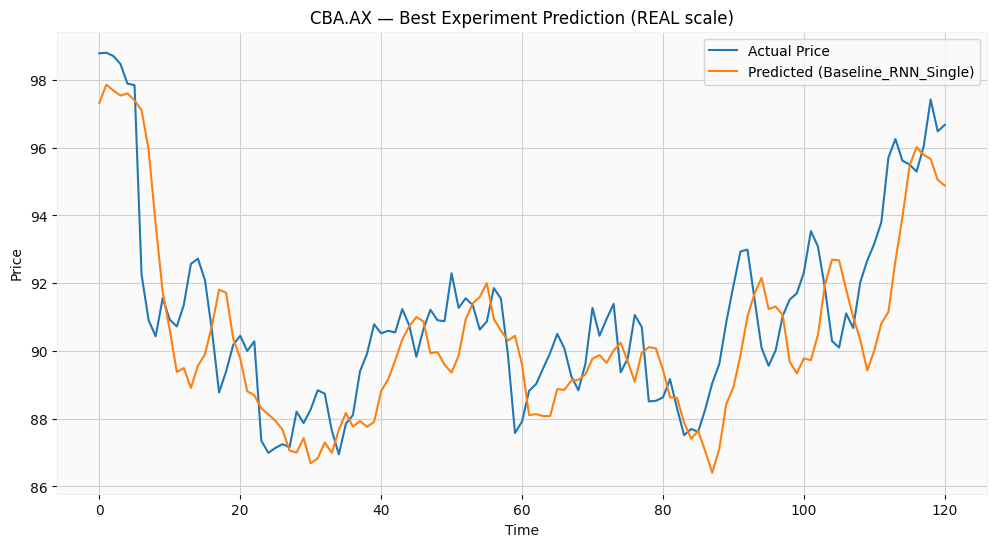

In [72]:
# Section 6B — C.4 Comprehensive Experiments 

def run_comprehensive_experiments(X_train, y_train, X_test, y_test, configs):
    results = []
    print("\n------------------------------------------------------------------")
    print(f"Total experiments to run: {len(configs)}")
    for i, cfg in enumerate(configs, 1):
        print(f"[{i}/{len(configs)}] {cfg['name']} — {cfg['layer_type']} {cfg['layer_sizes']}, "
              f"epochs={cfg['epochs']}, batch={cfg['batch_size']}, dropout={cfg['dropout']}")
        try:
            model = build_dl_model(
                layer_type=cfg["layer_type"], 
                layer_sizes=cfg["layer_sizes"], 
                input_shape=(TIME_STEP, 1),
                dropout=cfg["dropout"]
            )
            hist = model.fit(
                X_train, y_train, 
                epochs=cfg["epochs"], batch_size=cfg["batch_size"],
                validation_data=(X_test, y_test),
                verbose=0, shuffle=False
            )
            preds = model.predict(X_test, verbose=0).ravel()

            ytest_real = target_scaler.inverse_transform(y_test.reshape(-1,1)).ravel()
            preds_real = target_scaler.inverse_transform(preds.reshape(-1,1)).ravel()
            rmse = math.sqrt(mean_squared_error(ytest_real, preds_real))
            mae  = mean_absolute_error(ytest_real, preds_real)

            train_loss = float(hist.history['loss'][-1])
            val_loss   = float(hist.history['val_loss'][-1])

            results.append({
                "experiment_id": i,
                "experiment_name": cfg["name"],
                "model_type": cfg["layer_type"],
                "layer_architecture": str(cfg["layer_sizes"]),
                "epochs": int(cfg["epochs"]),
                "batch_size": int(cfg["batch_size"]),
                "dropout": float(cfg["dropout"]),
                "final_train_loss": train_loss,
                "final_val_loss": val_loss,
                "rmse_real": rmse,
                "mae_real": mae,
                "status": "Success"
            })
        except Exception as e:
            results.append({
                "experiment_id": i,
                "experiment_name": cfg.get("name", f"exp_{i}"),
                "model_type": cfg.get("layer_type", "NA"),
                "layer_architecture": str(cfg.get("layer_sizes")),
                "epochs": cfg.get("epochs"), "batch_size": cfg.get("batch_size"),
                "dropout": cfg.get("dropout"),
                "final_train_loss": None, "final_val_loss": None,
                "rmse_real": None, "mae_real": None,
                "status": "Failed", "error_message": str(e)
            })
            print(f"   FAILED: {e}")

    print("All experiments completed.")
    return pd.DataFrame(results)

# Build Close-only sequences for experiments 
close_scaled = target_scaler.transform(df[[CLOSE_COL]]).astype(float)
cut = int(len(close_scaled) * (1 - TEST_SIZE))
train_close, test_close = close_scaled[:cut], close_scaled[cut:]
X_train_seq, y_train_seq = make_sequences(train_close, time_step=TIME_STEP)
X_test_seq,  y_test_seq  = make_sequences(test_close,  time_step=TIME_STEP)
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_test_seq  = X_test_seq.reshape((X_test_seq.shape[0],  X_test_seq.shape[1],  1))

print(f"X_train_seq: {X_train_seq.shape} | X_test_seq: {X_test_seq.shape}")

if 'configs' not in globals():
    configs = [
        {"name":"Baseline_LSTM_Single","layer_type":"LSTM","layer_sizes":[50],"epochs":15,"batch_size":32,"dropout":0.2},
        {"name":"Baseline_GRU_Single","layer_type":"GRU","layer_sizes":[50],"epochs":15,"batch_size":32,"dropout":0.2},
        {"name":"Baseline_RNN_Single","layer_type":"RNN","layer_sizes":[50],"epochs":15,"batch_size":32,"dropout":0.2},
    ]

results_df = run_comprehensive_experiments(X_train_seq, y_train_seq, X_test_seq, y_test_seq, configs)
succ = results_df[results_df['status']=="Success"].copy()
if not succ.empty:
    succ = succ.sort_values("rmse_real")
    print("\nTop 5 models by RMSE (real scale):")
    print(succ.head(5)[["experiment_name","model_type","layer_architecture","rmse_real","mae_real"]].to_string(index=False))
    best_name = succ.iloc[0]["experiment_name"]
    best_cfg  = next(c for c in configs if c["name"] == best_name)

    # Refit best and plot 
    best_model = build_dl_model(best_cfg["layer_type"], best_cfg["layer_sizes"], (TIME_STEP,1), best_cfg["dropout"])
    best_model.fit(X_train_seq, y_train_seq, epochs=int(best_cfg["epochs"]), batch_size=int(best_cfg["batch_size"]), verbose=0)
    best_pred = best_model.predict(X_test_seq, verbose=0).ravel()
    y_test_real = target_scaler.inverse_transform(y_test_seq.reshape(-1,1)).ravel()
    best_pred_real = target_scaler.inverse_transform(best_pred.reshape(-1,1)).ravel()

    plt.figure(figsize=(12,6))
    plt.plot(y_test_real, label="Actual Price")
    plt.plot(best_pred_real, label=f"Predicted ({best_name})")
    plt.title(f"{COMPANY} — Best Experiment Prediction (REAL scale)")
    plt.xlabel("Time"); plt.ylabel("Price"); plt.legend(); plt.show()
else:
    print("No successful experiments to analyse.")


Finding best ARIMA(p,d,q) parameters...
Best ARIMA order found: (5, 1, 5)
ARIMA  RMSE: 3.2858 | MAE: 2.8470
LSTM   RMSE: 3.9526 | MAE: 3.1796
Ensemble (Mean)     RMSE: 3.4992
Ensemble (Weighted) RMSE: 3.4684  (weights ARIMA=0.546, LSTM=0.454)


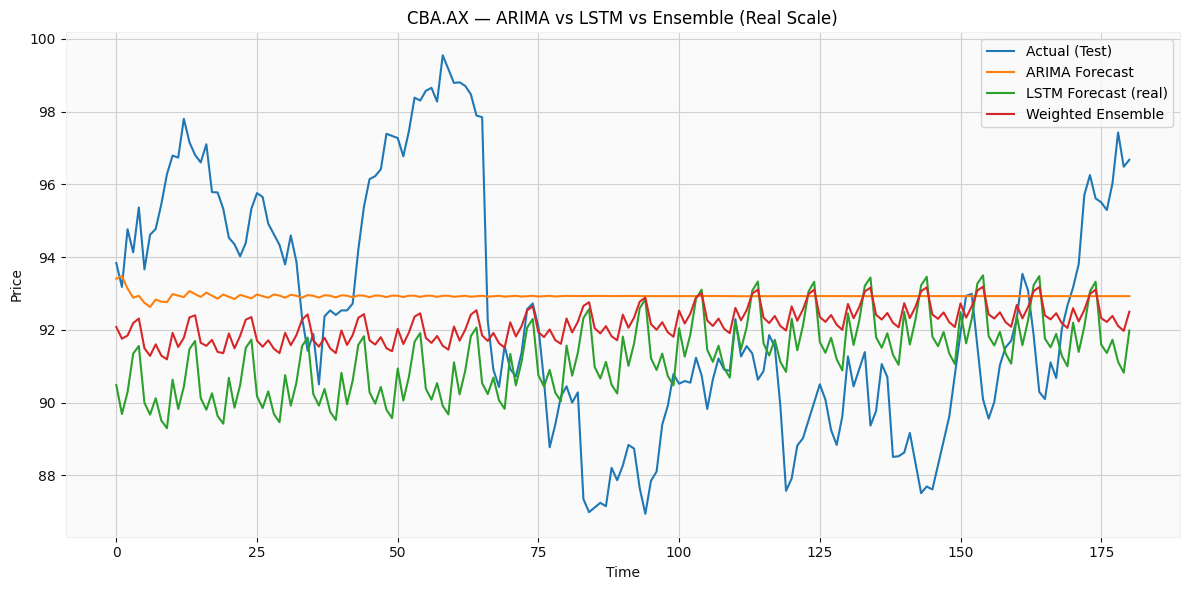

In [ ]:
# Section 7 — ARIMA/SARIMA + Ensemble (fixed & aligned)
from pmdarima import auto_arima
import warnings; warnings.filterwarnings("ignore")

# Train/Test split on REAL Close prices (pandas Series)
train = df[CLOSE_COL].astype(float).iloc[:int(len(df)*(1 - TEST_SIZE))]
test  = df[CLOSE_COL].astype(float).iloc[ int(len(df)*(1 - TEST_SIZE)) :]

print("Finding best ARIMA(p,d,q) parameters...")
auto_model = auto_arima(
    train,
    start_p=0, start_q=0, max_p=5, max_q=5,
    d=None, seasonal=False, stepwise=True, trace=False,
    error_action="ignore", suppress_warnings=True
)
best_order = auto_model.order
print(f"Best ARIMA order found: {best_order}")

# ARIMA forecast for exactly len(test) steps (NumPy array)
arima_forecast = auto_model.predict(n_periods=len(test))
arima_forecast = np.asarray(arima_forecast, dtype=float)

# LSTM predictions from Section 6 (REAL scale) — must exist
if 'y_pred_mvms_real_test' not in globals():
    raise RuntimeError("y_pred_mvms_real_test not found. Run Section 6 to compute LSTM test predictions (real scale) first.")

# Make lengths consistent and coerce to NumPy
lstm_predictions = np.asarray(y_pred_mvms_real_test, dtype=float)
min_len = int(min(len(test), len(arima_forecast), len(lstm_predictions)))

truth_np = np.asarray(test.iloc[:min_len], dtype=float)
arima_np = arima_forecast[:min_len]
lstm_np  = lstm_predictions[:min_len]

# Metrics per model
from math import sqrt
arima_rmse = sqrt(mean_squared_error(truth_np, arima_np))
arima_mae  = mean_absolute_error(truth_np, arima_np)
lstm_rmse  = sqrt(mean_squared_error(truth_np, lstm_np))
lstm_mae   = mean_absolute_error(truth_np, lstm_np)
print(f"ARIMA  RMSE: {arima_rmse:.4f} | MAE: {arima_mae:.4f}")
print(f"LSTM   RMSE: {lstm_rmse:.4f} | MAE: {lstm_mae:.4f}")

# Ensembles
# Mean blend
ens_mean = 0.5 * arima_np + 0.5 * lstm_np

# Weighted by inverse RMSE (lower RMSE - higher weight)
wa = 1.0 / max(arima_rmse, 1e-9)
wl = 1.0 / max(lstm_rmse, 1e-9)
wa, wl = wa / (wa + wl), wl / (wa + wl)
ens_w = wa * arima_np + wl * lstm_np

ens_mean_rmse = sqrt(mean_squared_error(truth_np, ens_mean))
ens_w_rmse    = sqrt(mean_squared_error(truth_np, ens_w))
print(f"Ensemble (Mean)     RMSE: {ens_mean_rmse:.4f}")
print(f"Ensemble (Weighted) RMSE: {ens_w_rmse:.4f}  (weights ARIMA={wa:.3f}, LSTM={wl:.3f})")

# Plot with a shared x-axis
x = np.arange(min_len)
plt.figure(figsize=(12,6))
plt.plot(x, truth_np,  label="Actual (Test)")
plt.plot(x, arima_np,  label="ARIMA Forecast")
plt.plot(x, lstm_np,   label="LSTM Forecast (real)")
plt.plot(x, ens_w,     label="Weighted Ensemble")
plt.title(f"{COMPANY} — ARIMA vs LSTM vs Ensemble (Real Scale)")
plt.xlabel("Time"); plt.ylabel("Price"); plt.legend()
plt.tight_layout(); plt.show()


In [ ]:
# Section 7A — Simple Ensemble Helper
def simple_ensemble(pred_list, weights=None):
    
    arr = [np.asarray(p) for p in pred_list]
    if weights is None:
        return np.mean(arr, axis=0)
    w = np.asarray(weights, dtype=float)
    w = w / w.sum()
    stacked = np.stack(arr, axis=0)
    while w.ndim < stacked.ndim:
        w = w[..., None]
    return np.sum(w * stacked, axis=0)


In [ ]:
# Section 9 — Text Sentiment: train on Sentiment_Stock_data.csv, score news_daily_raw.csv
# Load CSVs
f_raw = "news_daily_raw.csv"          # has 'date' and 'text'
f_labelled = "Sentiment_Stock_data.csv"  # NO date; has 'Sentence' + 'Sentiment'
assert os.path.exists(f_raw) and os.path.exists(f_labelled), "CSV files not found."

news_raw = pd.read_csv(f_raw)
lab = pd.read_csv(f_labelled)

# Normalise columns 
# news_raw - ['date', 'text']
news_raw.columns = [c.strip().lower() for c in news_raw.columns]
date_col = [c for c in news_raw.columns if "date" in c][0]
text_col = [c for c in news_raw.columns if c in ("text","headline","title","content")][0]
news_raw = news_raw.rename(columns={date_col:"Date", text_col:"text"})
news_raw["Date"] = pd.to_datetime(news_raw["Date"], errors="coerce").dt.tz_localize(None).dt.normalize()

# lab - ['Sentence','Sentiment']  (1=pos, 0=neg)
lab.columns = [c.strip() for c in lab.columns]
assert "Sentence" in lab.columns and "Sentiment" in lab.columns, lab.columns

def clean_text(s: str) -> str:
    s = str(s)
    s = re.sub(r"http\S+|www\.\S+|[@#]\w+"," ", s)
    s = re.sub(r"[^A-Za-z0-9 .,!?$%\-+()]", " ", s)
    return re.sub(r"\s+"," ", s).strip()

news_raw["text_clean"] = news_raw["text"].map(clean_text)
lab["text_clean"] = lab["Sentence"].map(clean_text)

# Train a simple text-sentiment classifier on labelled dataset 
X_tr_text, X_te_text, y_tr_text, y_te_text = train_test_split(
    lab["text_clean"], lab["Sentiment"].astype(int), test_size=0.2, random_state=42, stratify=lab["Sentiment"]
)

tfidf = TfidfVectorizer(min_df=2, ngram_range=(1,2), max_features=30000)
Xtr = tfidf.fit_transform(X_tr_text)
Xte = tfidf.transform(X_te_text)

sent_clf = LogisticRegression(max_iter=1000)
sent_clf.fit(Xtr, y_tr_text)
pred = sent_clf.predict(Xte)
print(f"[Text Sentiment Model] Acc={accuracy_score(y_te_text, pred):.3f} | F1={f1_score(y_te_text, pred):.3f}")

# Score the news file with two sentiment sources: ML (prob) and VADER (compound) 
X_news = tfidf.transform(news_raw["text_clean"])
news_raw["sent_ml_prob"] = sent_clf.predict_proba(X_news)[:,1]   # 0..1, higher = more positive

try:
    sia = SentimentIntensityAnalyzer()
except Exception:
    nltk.download("vader_lexicon")
    sia = SentimentIntensityAnalyzer()
vader = news_raw["text_clean"].map(sia.polarity_scores)
vader_df = pd.DataFrame(list(vader))   # neg, neu, pos, compound
news_raw = pd.concat([news_raw, vader_df.add_prefix("vader_")], axis=1)

# Aggregate to daily sentiment (mean) ---
sent_daily = (news_raw.groupby("Date", as_index=False)
              .agg(sent_ml_prob_mean=("sent_ml_prob","mean"),
                   vader_neg=("vader_neg","mean"),
                   vader_neu=("vader_neu","mean"),
                   vader_pos=("vader_pos","mean"),
                   vader_compound=("vader_compound","mean"),
                   sent_count=("text","count")))

print("Daily sentiment shape:", sent_daily.shape)
display(sent_daily.head(10))


[Text Sentiment Model] Acc=0.529 | F1=0.559
Daily sentiment shape: (1, 7)


,Date,sent_ml_prob_mean,vader_neg,vader_neu,vader_pos,vader_compound,sent_count
0,2025-10-31,0.515689,0.077,0.846,0.077,0.0,3


In [ ]:
# Section 10 — Merge Sentiment with Stock Prices
# Use existing bundle from load_process_data 
ticker = "AAPL" 
bundle = load_process_data(
    ticker=ticker, start="2018-01-01", end="2025-01-01",
    split_mode="date", split_arg="2024-01-01",
    cache_path="cache/AAPL.csv",      # CSV path now
    scaler_path="cache/AAPL_scaler.joblib"
)

df_all = bundle["df"].copy().reset_index()
df_all.rename(columns={"index":"Date"}, inplace=True)
df_all["Date"] = pd.to_datetime(df_all["Date"]).dt.tz_localize(None).dt.normalize()

cls = pd.merge(df_all, sent_daily, on="Date", how="left")
cls = cls.fillna(0)

# Label: 1 if next day's Close > today's Close
cls["up_next"] = (cls["Close"].shift(-1) > cls["Close"]).astype(int)
cls = cls.dropna(subset=["up_next"])

print("Classification frame:", cls.shape)
display(cls.head())


Classification frame: (1761, 13)


,Date,Close,High,Low,Open,Volume,sent_ml_prob_mean,vader_neg,vader_neu,vader_pos,vader_compound,sent_count,up_next
0,2018-01-02,40.380993,40.390372,39.677736,39.888715,102223600,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2018-01-03,40.373955,40.917808,40.310664,40.444281,118071600,0.0,0.0,0.0,0.0,0.0,0.0,1
2,2018-01-04,40.561493,40.664638,40.338796,40.446626,89738400,0.0,0.0,0.0,0.0,0.0,0.0,1
3,2018-01-05,41.023304,41.110038,40.566188,40.657611,94640000,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2018-01-08,40.870945,41.166312,40.772486,40.870945,82271200,0.0,0.0,0.0,0.0,0.0,0.0,0


In [77]:
# Section 11 — Simple features + 3 models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Simple technical features
cls["ret_1d"] = cls["Close"].pct_change(1)
cls["ret_5d"] = cls["Close"].pct_change(5)
cls["ma_5"]  = cls["Close"].rolling(5).mean()
cls["ma_10"] = cls["Close"].rolling(10).mean()
cls["ma_ratio_5_10"] = cls["ma_5"] / (cls["ma_10"] + 1e-8)
cls["hl_spread"] = (cls["High"] - cls["Low"]) / (cls["Close"] + 1e-8)
cls = cls.dropna()

price_feats = ["ret_1d","ret_5d","ma_ratio_5_10","hl_spread"]
sent_feats  = ["sent_ml_prob_mean","vader_compound","vader_pos","vader_neg","vader_neu","sent_count"]

# Baseline vs With Sentiment
Xp = cls[price_feats].fillna(0).values
Xs = cls[price_feats + sent_feats].fillna(0).values
y  = cls["up_next"].astype(int).values

split_date = pd.to_datetime("2024-01-01")
mask_tr = cls["Date"] < split_date
mask_te = cls["Date"] >= split_date

Xp_tr, Xp_te = Xp[mask_tr], Xp[mask_te]
Xs_tr, Xs_te = Xs[mask_tr], Xs[mask_te]
y_tr,  y_te  = y[mask_tr],  y[mask_te]

models = {
    "Logistic": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoost": GradientBoostingClassifier(random_state=42)
}

print(" BASELINE (price only)")
for name, mdl in models.items():
    mdl.fit(Xp_tr, y_tr)
    p = mdl.predict(Xp_te)
    print(f"{name}: Acc={accuracy_score(y_te,p):.3f} | F1={f1_score(y_te,p):.3f}")
    print("CM:\n", confusion_matrix(y_te,p))

print("\n WITH SENTIMENT (price + sentiment)")
for name, mdl in models.items():
    mdl.fit(Xs_tr, y_tr)
    p = mdl.predict(Xs_te)
    print(f"{name}: Acc={accuracy_score(y_te,p):.3f} | F1={f1_score(y_te,p):.3f}")
    print("CM:\n", confusion_matrix(y_te,p))


 BASELINE (price only)
Logistic: Acc=0.563 | F1=0.721
CM:
 [[  0 110]
 [  0 142]]
RandomForest: Acc=0.524 | F1=0.583
CM:
 [[48 62]
 [58 84]]
GradientBoost: Acc=0.563 | F1=0.660
CM:
 [[ 35  75]
 [ 35 107]]

 WITH SENTIMENT (price + sentiment)
Logistic: Acc=0.563 | F1=0.721
CM:
 [[  0 110]
 [  0 142]]
RandomForest: Acc=0.552 | F1=0.604
CM:
 [[53 57]
 [56 86]]
GradientBoost: Acc=0.560 | F1=0.658
CM:
 [[ 34  76]
 [ 35 107]]



BASELINE (price only) 
Logistic: Accuracy=0.563, F1=0.721
RandomForest: Accuracy=0.540, F1=0.597
GradientBoost: Accuracy=0.563, F1=0.660

WITH SENTIMENT 
Logistic: Accuracy=0.563, F1=0.721
RandomForest: Accuracy=0.544, F1=0.613
GradientBoost: Accuracy=0.560, F1=0.658


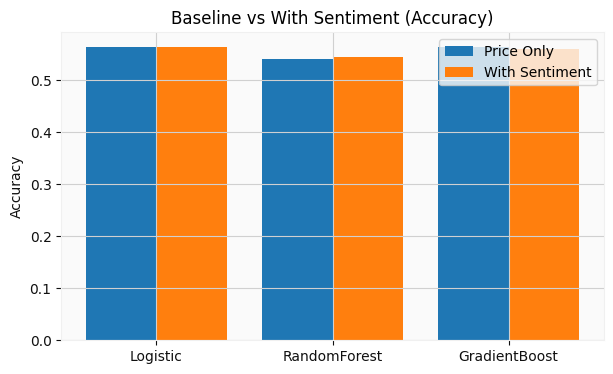


Best with-sentiment model by Accuracy: Logistic
Confusion matrix (rows=true, cols=pred):
 [[  0 110]
 [  0 142]]

Classification report:
               precision    recall  f1-score   support

           0      0.000     0.000     0.000       110
           1      0.563     1.000     0.721       142

    accuracy                          0.563       252
   macro avg      0.282     0.500     0.360       252
weighted avg      0.318     0.563     0.406       252



In [ ]:
# Section 12 — Compare baseline (price only) vs with sentiment (FINAL)
# Price-only engineered features created earlier
price_only_cols = ["ret_1d", "ret_5d", "ma_ratio_5_10", "hl_spread"]
missing = [c for c in price_only_cols if c not in cls.columns]
if missing:
    raise ValueError(f"These price-only columns are missing from 'cls': {missing}")

# 1) Make sure classification label exists
if "up_next" in cls.columns:
    label_col = "up_next"
elif "rise_next" in cls.columns:
    label_col = "rise_next"
else:
    # Create it now: 1 if next day's Close > today's Close
    cls["up_next"] = (cls["Close"].shift(-1) > cls["Close"]).astype(int)
    cls.dropna(subset=["up_next"], inplace=True)
    label_col = "up_next"

# 2) Sentiment feature columns (robust)
sent_cols = []
candidates = ["neg","neu","pos","compound","sent_compound","vader_neg","vader_neu","vader_pos","vader_compound"]
for c in candidates:
    if c in cls.columns:
        sent_cols.append(c)
# also include any columns you prefixed like "sent_*"
sent_cols += [c for c in cls.columns if c.startswith("sent_") and c not in sent_cols]
sent_cols = sorted(list(dict.fromkeys(sent_cols)))  # unique & stable order
if not sent_cols:
    raise ValueError("No sentiment columns found. Check your Section 9 aggregation created 'sent_daily' and merged it into 'cls'.")

# 3) Define the two feature sets
feature_cols = price_only_cols + sent_cols

# 4) Train/test split 
if "Date" in cls.columns:
    split_date = pd.to_datetime("2024-01-01")
    tr_mask = cls["Date"] < split_date
    te_mask = cls["Date"] >= split_date
else:
    # Fallback: 80/20 index split
    N = len(cls)
    split = int(N * 0.8)
    idx = np.arange(N)
    tr_mask = idx < split
    te_mask = idx >= split

Xp = cls[price_only_cols].fillna(0).values
Xs = cls[feature_cols].fillna(0).values
y  = cls[label_col].astype(int).values

Xp_tr, Xp_te = Xp[tr_mask], Xp[te_mask]
Xs_tr, Xs_te = Xs[tr_mask], Xs[te_mask]
y_tr,  y_te  = y[tr_mask],  y[te_mask]

# Models 
models = {
    "Logistic": LogisticRegression(max_iter=300),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoost": GradientBoostingClassifier(random_state=42)
}

print("\nBASELINE (price only) ")
baseline_results, baseline_preds = {}, {}
for name, mdl in models.items():
    mdl.fit(Xp_tr, y_tr)
    p = mdl.predict(Xp_te)
    baseline_preds[name] = p
    baseline_results[name] = (accuracy_score(y_te, p), f1_score(y_te, p))
    print(f"{name}: Accuracy={baseline_results[name][0]:.3f}, F1={baseline_results[name][1]:.3f}")

print("\nWITH SENTIMENT ")
sent_results, sent_preds = {}, {}
for name, mdl in models.items():
    mdl.fit(Xs_tr, y_tr)
    p = mdl.predict(Xs_te)
    sent_preds[name] = p
    sent_results[name] = (accuracy_score(y_te, p), f1_score(y_te, p))
    print(f"{name}: Accuracy={sent_results[name][0]:.3f}, F1={sent_results[name][1]:.3f}")

# Simple visual comparison (Accuracy)
x = np.arange(len(models))
baseline_acc = [baseline_results[k][0] for k in models.keys()]
sent_acc     = [sent_results[k][0]   for k in models.keys()]

plt.figure(figsize=(7,4))
plt.bar(x-0.2, baseline_acc, 0.4, label='Price Only')
plt.bar(x+0.2, sent_acc, 0.4, label='With Sentiment')
plt.xticks(x, list(models.keys()))
plt.ylabel('Accuracy')
plt.title('Baseline vs With Sentiment (Accuracy)')
plt.legend()
plt.show()

# Print a confusion matrix for the best "with sentiment" model
best_name = max(sent_results.items(), key=lambda kv: kv[1][0])[0]  # by Accuracy
print(f"\nBest with-sentiment model by Accuracy: {best_name}")
cm = confusion_matrix(y_te, sent_preds[best_name])
print("Confusion matrix (rows=true, cols=pred):\n", cm)
print("\nClassification report:\n", classification_report(y_te, sent_preds[best_name], digits=3))
